# **Общие приготовления**

In [2]:
# импортируем зависимости
import torch

import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets
from torchvision.transforms import ToTensor
from torch.utils.data import DataLoader
from torchinfo import summary
from torch import nn

Загружаем датасет, по отдельности скачав выборки train и test (fashion MNIST)

In [23]:
train_dataset = datasets.FashionMNIST(root='mnist', train=True, download=True, transform=ToTensor())
test_dataset = datasets.FashionMNIST(root="mnist", train=False, download=True, transform=ToTensor())
train_dataset, valid_dataset = torch.utils.data.random_split(train_dataset, [50000, 10000])

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=8, pin_memory=True)
valid_loader = DataLoader(valid_dataset, batch_size=128, shuffle=False, num_workers=8, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False, num_workers=8, pin_memory=True)

Выберем функцию лосса


In [4]:
loss_function = nn.CrossEntropyLoss()

Возьмём train (из файла семинара)

In [5]:
import torch.nn as nn
from torch.utils.data import DataLoader
from torch.optim import Optimizer
from tqdm import tqdm


def train(model: nn.Module, data_loader: DataLoader, optimizer: Optimizer, loss_fn, device: torch.device):
    model.train()

    total_loss = 0
    total_correct = 0

    for x, y in tqdm(data_loader):
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()

        output = model(x)

        loss = loss_fn(output, y)

        loss.backward()

        total_loss += loss.item()

        total_correct += (output.argmax(dim=1) == y).sum().item()

        optimizer.step()

    return total_loss / len(data_loader), total_correct / len(data_loader.dataset)

Функция для вывода вала модели (из файла семинара)

In [6]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader


@torch.inference_mode()
def evaluate(model: nn.Module, data_loader: DataLoader, loss_fn, device: torch.device):
    model.eval()

    total_loss = 0
    total_correct = 0

    for x, y in tqdm(data_loader):
        x, y = x.to(device), y.to(device)

        output = model(x)

        loss = loss_fn(output, y)

        total_loss += loss.item()

        total_correct += (output.argmax(dim=1) == y).sum().item()

    return total_loss / len(data_loader), total_correct / len(data_loader.dataset)

Функция для показа графиков обучения (из файла семинара)

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns


sns.set(style='darkgrid')


def plot_stats(
    train_loss: list[float],
    valid_loss: list[float],
    train_accuracy: list[float],
    valid_accuracy: list[float],
    title: str
):
    plt.figure(figsize=(16, 8))

    plt.title(title + ' loss')

    plt.plot(train_loss, label='Train loss')
    plt.plot(valid_loss, label='Valid loss')
    plt.legend()

    plt.show()

    plt.figure(figsize=(16, 8))

    plt.title(title + ' accuracy')

    plt.plot(train_accuracy, label='Train accuracy')
    plt.plot(valid_accuracy, label='Valid accuracy')
    plt.legend()

    plt.show()

Окончательная функция обучения

In [8]:
from IPython.display import clear_output


def fit(model, train_loader, valid_loader, optimizer, loss_fn, device, num_epochs, title):
    train_loss_history, valid_loss_history = [], []
    train_accuracy_history, valid_accuracy_history = [], []

    for epoch in range(num_epochs):
        train_loss, train_accuracy = train(model, train_loader, optimizer, loss_fn, device)
        valid_loss, valid_accuracy = evaluate(model, valid_loader, loss_fn, device)

        train_loss_history.append(train_loss)
        valid_loss_history.append(valid_loss)

        train_accuracy_history.append(train_accuracy)
        valid_accuracy_history.append(valid_accuracy)

        clear_output()

        plot_stats(
            train_loss_history, valid_loss_history,
            train_accuracy_history, valid_accuracy_history,
            title
        )

        # torch.save(model.state_dict(), f"checkpoints/model_{epoch}.pt")
        # torch.save(optimizer.state_dict(), f"checkpoints/optimizer_{epoch}.pt")

Функция для проверки результатов после обучения

In [9]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader


@torch.inference_mode()
def predict(model: nn.Module, loader: DataLoader, device: torch.device):
    model.eval()

    prediction = []

    for x, _ in tqdm(loader):
        output = model(x.to(device)).cpu()

        prediction.append(torch.argmax(output, dim=1))

    prediction = torch.cat(prediction)

    return prediction


И навсякий функция для проверки остальных метрик, хоть в теории она нам понадобится, чтобы оценить датасет первый раз, всё же в классификации, особенно таких картинок accuracity главная

In [10]:
from sklearn.metrics import precision_recall_fscore_support, accuracy_score


def classification_metrics(labels, preds):

    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='macro', zero_division=0)
    acc = accuracy_score(labels, preds)

    return acc, precision, recall, f1

Ставим Cuda ядра (если они есть)

In [11]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

print(device)
print(torch.cuda.get_device_name())

cuda:0
NVIDIA GeForce RTX 3050 Ti Laptop GPU


Функция, которая берёт label с датасета

In [12]:
def get_labels(loader):
    labels = []

    for _, y in tqdm(loader):
        labels.append(y)

    return torch.cat(labels, dim=0)

Проверим, сколько классов в fashionMNIST и размер картинок

In [13]:
print(len(train_dataset.classes)) # 10 классов
print(train_dataset.classes)

print(train_dataset[0][0].shape, train_dataset[0][0].numel()) # 784

10
['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
torch.Size([1, 28, 28]) 784


Функция просмотра ошибок в классах

In [14]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

classes = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]

def plot_confusion_matrix(y_true, y_pred, classes):
    cm = confusion_matrix(y_true, y_pred)
    
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    plt.figure(figsize=(12, 10))
    sns.set(font_scale=1.1)
    
    sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap='Blues',
                xticklabels=classes, yticklabels=classes,
                square=True, cbar_kws={"shrink": .8})
    
    plt.ylabel('True Label', fontsize=14, fontweight='bold')
    plt.xlabel('Predicted Label', fontsize=14, fontweight='bold')
    plt.title('Normalized Confusion Matrix for Fashion-MNIST', fontsize=16, pad=20)
    
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

# **Задание 1 Написание базовой модели**

Задание: Скачайте датасет Fashion MNIST, посмотрите на картинки, отделите валидационную выборку и обучите одну полносвязную архитектуру. Выведите summary модели, посмотрите на графики обучения, сделайте выводы.

Возьму мою лучшую архитектуру из прошлого семинара с BatchNorm с lr=0.1 и Dropout, а саму модель буду обучать на SGD, так как мои модели с SGD более быстрый, чем Adam, и мои модель с ним получила более лучшие результаты

In [41]:
import torch.nn as nn
from torchsummary import summary

class MyBestModel(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.net = nn.Sequential(
            nn.Flatten(),
            
            nn.Linear(784, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, 10)
        )
    
    def forward(self, x):
        return self.net(x)
    

model = MyBestModel().to(device)
summary(model, input_size=(1, 28, 28))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
           Flatten-1                  [-1, 784]               0
            Linear-2                  [-1, 256]         200,960
       BatchNorm1d-3                  [-1, 256]             512
              ReLU-4                  [-1, 256]               0
           Dropout-5                  [-1, 256]               0
            Linear-6                  [-1, 128]          32,896
       BatchNorm1d-7                  [-1, 128]             256
              ReLU-8                  [-1, 128]               0
           Dropout-9                  [-1, 128]               0
           Linear-10                   [-1, 10]           1,290
Total params: 235,914
Trainable params: 235,914
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.02
Params size (MB): 0.90
Estimated T

Обучим первую и самую простую из них модельку

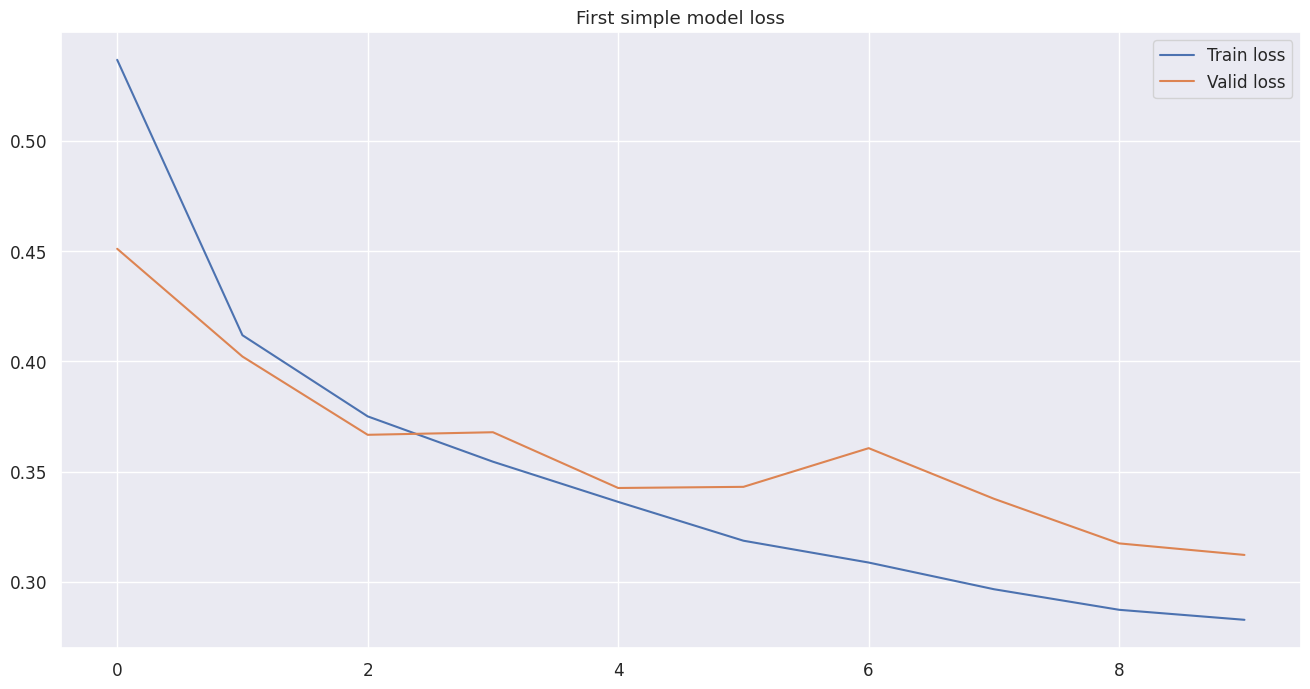

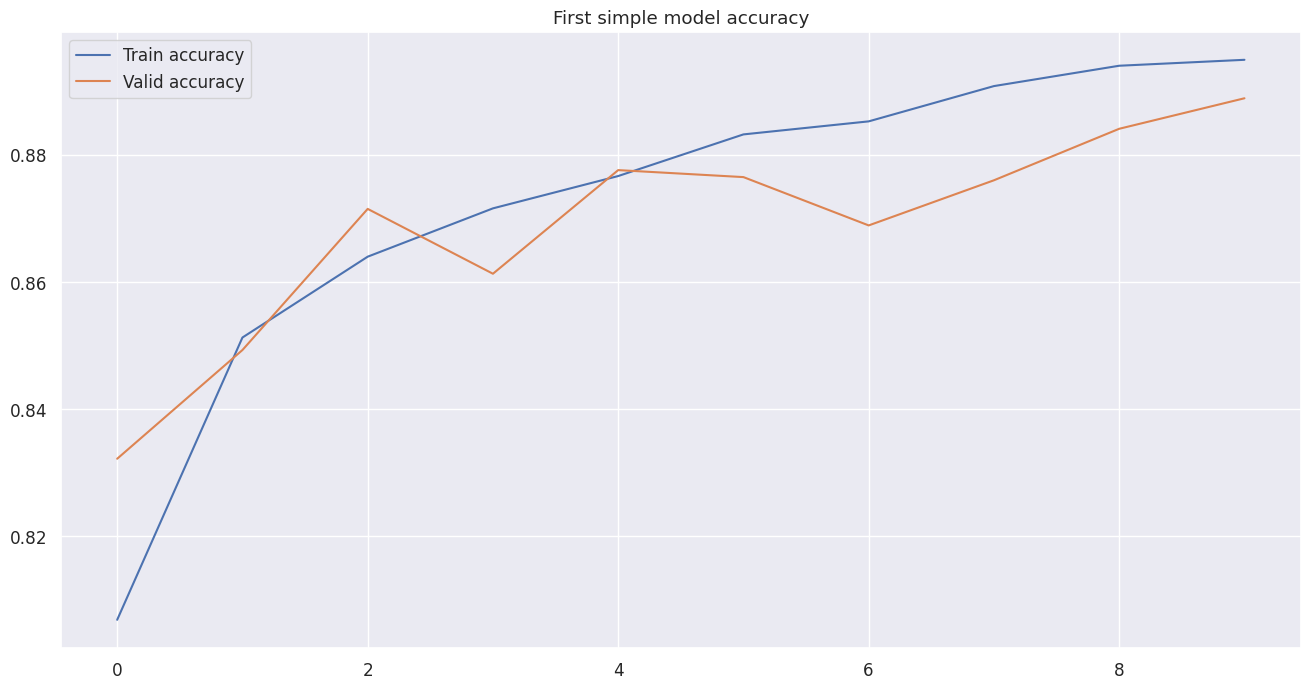

In [ ]:
from torch.optim import SGD


model = MyBestModel().to(device)

optimizer = SGD(model.parameters(), lr=0.1, momentum=0.9)

fit(model, train_loader, valid_loader, optimizer, loss_function, device, 10, 'First simple model')

10 эпох мало, график не сошёлся (не до конца)

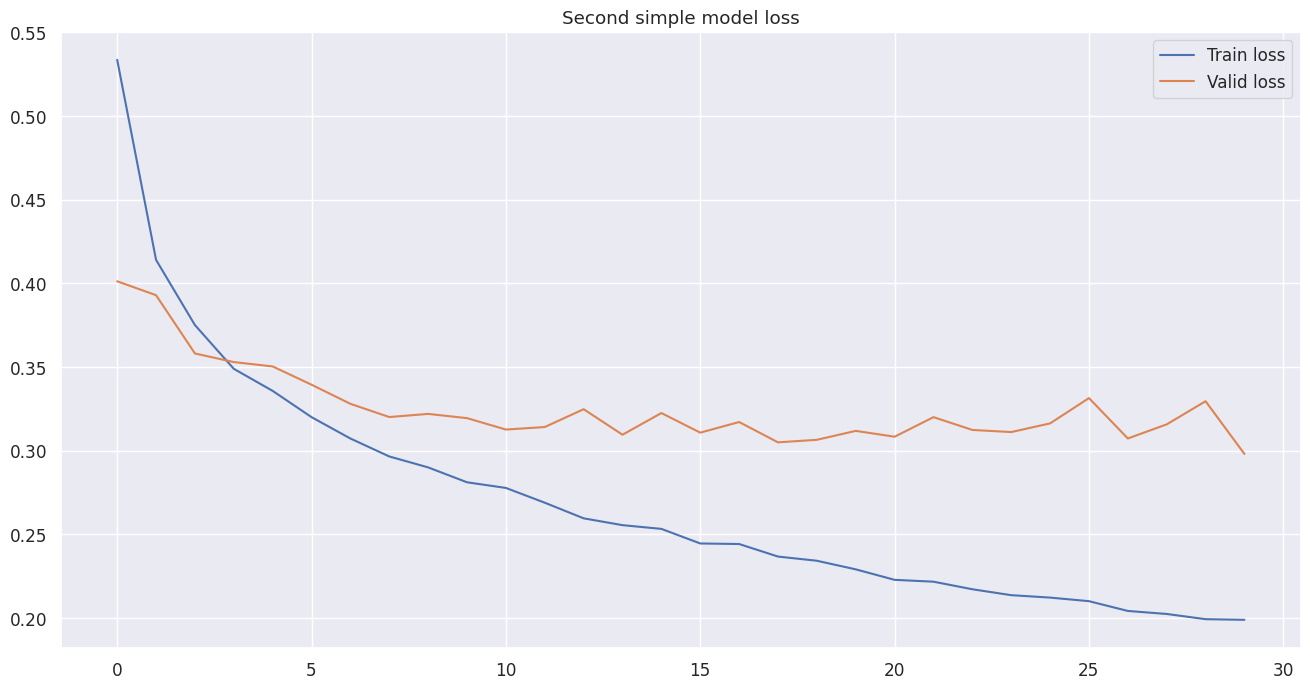

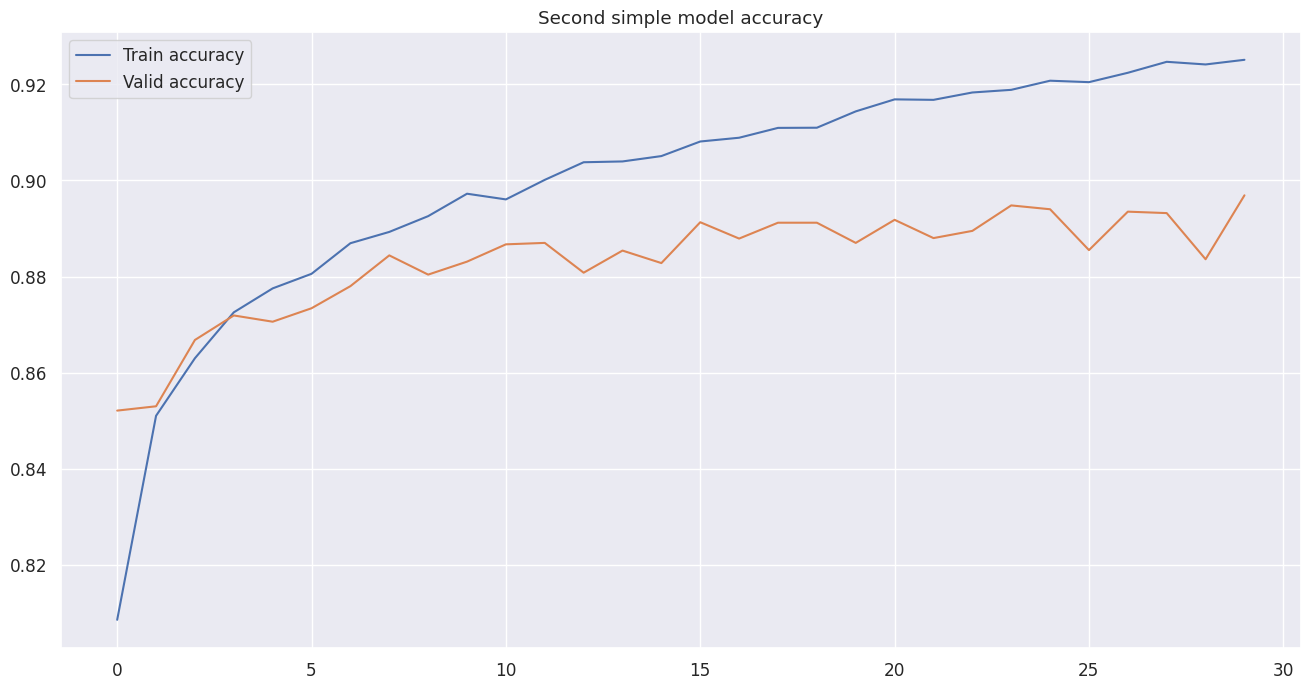

In [ ]:
from torch.optim import SGD


model = MyBestModel().to(device)

optimizer = SGD(model.parameters(), lr=0.1, momentum=0.9)

fit(model, train_loader, valid_loader, optimizer, loss_function, device, 30, 'Second simple model')

Так, а теперь мы видим, что произошло переобучение и, в общем, рост val loss и Accuracy остановился

Так или иначе сделаем проверку на val

In [77]:
prediction = predict(model, valid_loader, device)
labels = get_labels(valid_loader)

100%|██████████| 79/79 [00:00<00:00, 272.10it/s]


In [79]:
prediction

tensor([9, 2, 1,  ..., 8, 1, 5])

In [80]:
labels

tensor([9, 2, 1,  ..., 8, 1, 5])

In [81]:
torch.mean((prediction == labels).to(torch.float32))

tensor(0.8969)

In [ ]:
acc, precision, recall, f1 = classification_metrics(labels=labels, preds=prediction)

print(f"Accuracy: {acc}") # мы уже видели её выше tensor(0.8969)
print(f"Precision:  {precision:.4f}")
print(f"Recall:     {recall:.4f}")
print(f"F1-score:   {f1:.4f}")

Accuracity: 0.8969
Precision:  0.8969
Recall:     0.8969
F1-score:   0.8964


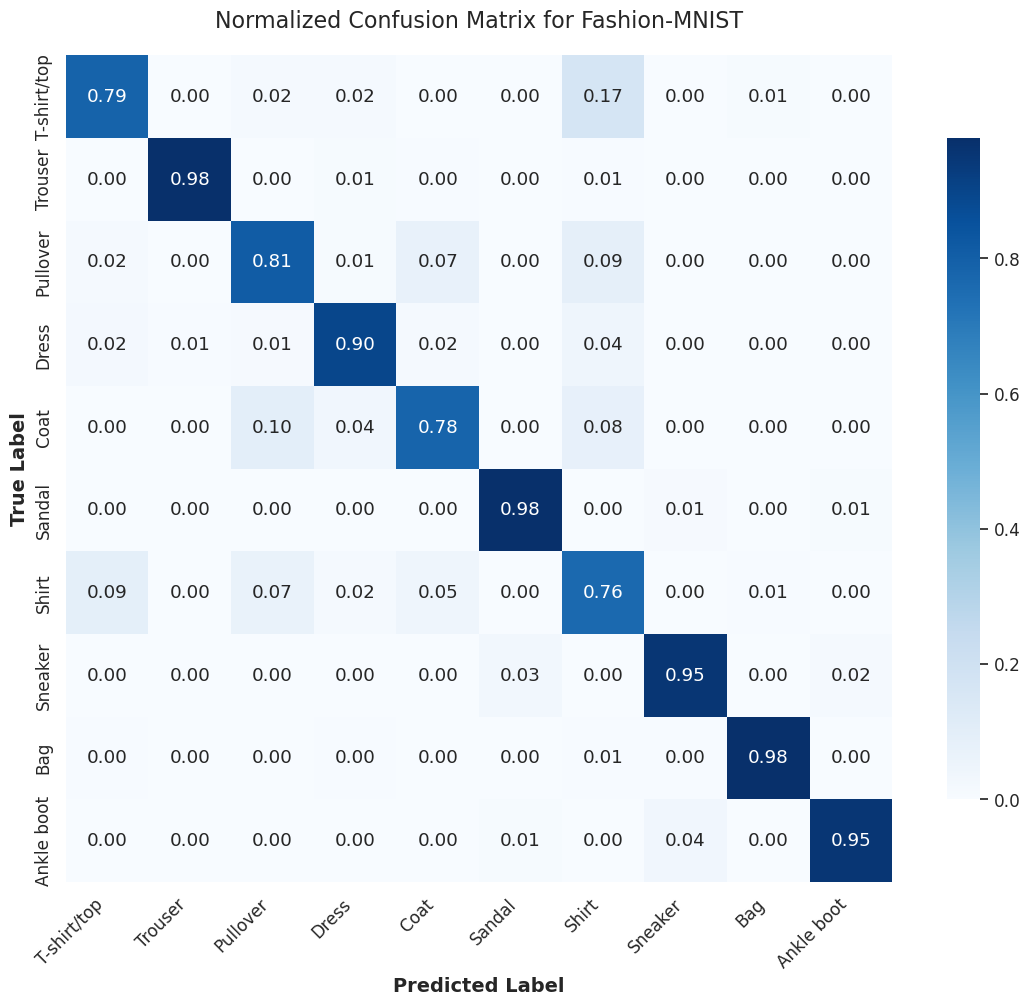

In [ ]:
plot_confusion_matrix(labels, prediction, classes)

#### **0.8969** 

В общем, вроде, для этого датасета нормальный score при обычном MLP, значит модель адекватная и работает как надо, даже параметров всего 200 тыс, что говорит о её легковесности 

Да и по остальным метрикам всё хорошо (они примерно равны), лишь можно сказать, что этот датасет сложнее, но у нас всё равно получилась довольно сбалансированная модель, а также датасет тоже хорошо сбалансирован

Если говорить о Confusion matrix, то мы видим, что модель особенно не хочет распознавать классы shirt и t-shirt, путая их друг с другом, а также pullover с coat

# **Задание 2 Свёртки**

Задание: Добавьте в архитектуру свёртки. Выведите summary модели, посмотрите на графики обучения, сделайте выводы.

Вспомним нашу архитектуру из прошлого задания

In [15]:
import torch.nn as nn
from torchsummary import summary

class MyBestModel(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.net = nn.Sequential(
            nn.Flatten(),
            
            nn.Linear(784, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, 10)
        )
    
    def forward(self, x):
        return self.net(x)
    

model = MyBestModel().to(device)
summary(model, input_size=(1, 28, 28))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
           Flatten-1                  [-1, 784]               0
            Linear-2                  [-1, 256]         200,960
       BatchNorm1d-3                  [-1, 256]             512
              ReLU-4                  [-1, 256]               0
           Dropout-5                  [-1, 256]               0
            Linear-6                  [-1, 128]          32,896
       BatchNorm1d-7                  [-1, 128]             256
              ReLU-8                  [-1, 128]               0
           Dropout-9                  [-1, 128]               0
           Linear-10                   [-1, 10]           1,290
Total params: 235,914
Trainable params: 235,914
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.02
Params size (MB): 0.90
Estimated T

Добавим же в неё свёртки

In [71]:
import torch.nn as nn
from torchsummary import summary

class MyModelConv(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.net = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding=1), # 28 x 28 x 16
            nn.BatchNorm2d(16),
            nn.ReLU(),

            nn.Conv2d(in_channels=16, out_channels=16, kernel_size=3, padding=1), # 28 x 28 x 16
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2), # 14 x 14 x 16


            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1), # 14 x 14 x 32
            nn.BatchNorm2d(32),
            nn.ReLU(),
            
            nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, padding=1), # 14 x 14 x 32
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.Dropout2d(0.1), # немного здесь (в свёртке) добавил дропаута (честно, практически ничего не поменялось)
            nn.MaxPool2d(2), # 7 x 7 x 32
        
            nn.Flatten(),

            # по итогу у нас 32 фильтра, 7 x 7 пикселей - 1568 
            nn.Dropout(0.5), # а этот дал неплохой эффект, он сделал так, что теперь трейн лосс догоняет вал лосс
            nn.Linear(1568, 128), # уменьшил количество параметров, как вы говорили
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.5), # этот был, он делал более стабильным обучение
            
            nn.Linear(128, 10)
        )
    
    def forward(self, x):
        x = self.net(x)
        return x
    

model = MyModelConv().to(device)
summary(model, input_size=(1, 28, 28))
# теперь у неё 200к параметров (так по итогу это уже совсем другая моделька)

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 16, 28, 28]             160
       BatchNorm2d-2           [-1, 16, 28, 28]              32
              ReLU-3           [-1, 16, 28, 28]               0
            Conv2d-4           [-1, 16, 28, 28]           2,320
       BatchNorm2d-5           [-1, 16, 28, 28]              32
              ReLU-6           [-1, 16, 28, 28]               0
         MaxPool2d-7           [-1, 16, 14, 14]               0
            Conv2d-8           [-1, 32, 14, 14]           4,640
       BatchNorm2d-9           [-1, 32, 14, 14]              64
             ReLU-10           [-1, 32, 14, 14]               0
           Conv2d-11           [-1, 32, 14, 14]           9,248
      BatchNorm2d-12           [-1, 32, 14, 14]              64
             ReLU-13           [-1, 32, 14, 14]               0
        Dropout2d-14           [-1, 32,

Запустим обучение (тут 6 вариантов)

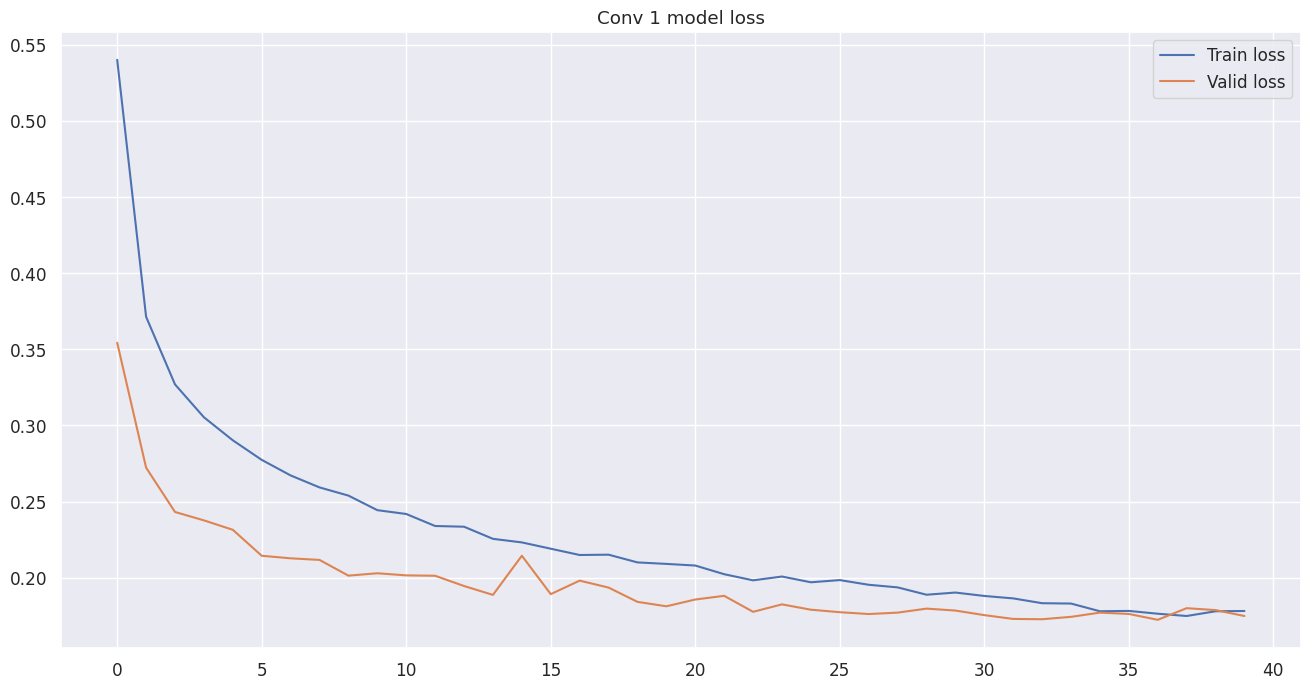

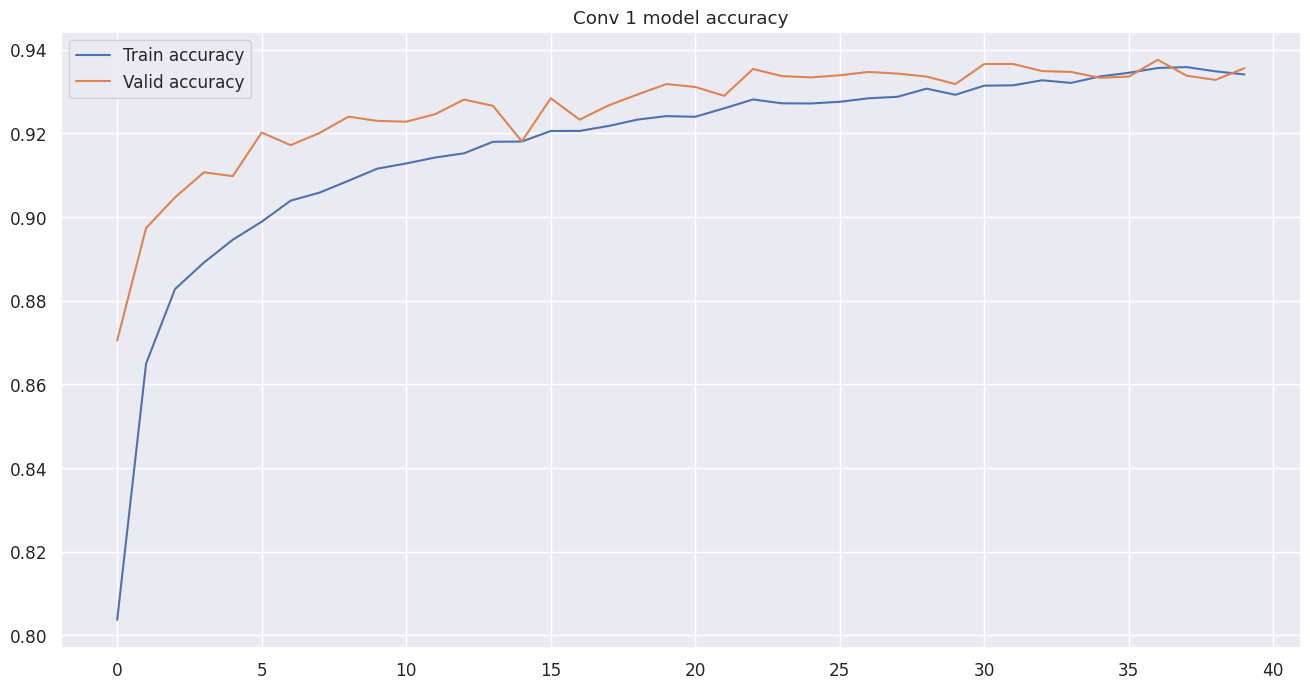

In [78]:
# 1 вариант SGD с lr=0.1
from torch.optim import SGD


model1 = MyModelConv().to(device)

optimizer = SGD(model1.parameters(), lr=0.1, momentum=0.9) 
# да, много, но (забыл из задания 1 вставить, lr=0.1 самый лучший score был так что оставлю)

fit(model1, train_loader, valid_loader, optimizer, loss_function, device, 40, 'Conv 1 model')

Он, конечно, дёрганый, но уже гораздо лучше, и как мы видим из-за dropout у нас вал лосс, меньше чем, трейн лосс, но обучение нестабильное, график нашёл своё плато аж в ~0.93 по акуратности, также по времени быстрый, что очень неплохо, хотя попробуем найти что-то лучше (другие гиперпараметры)

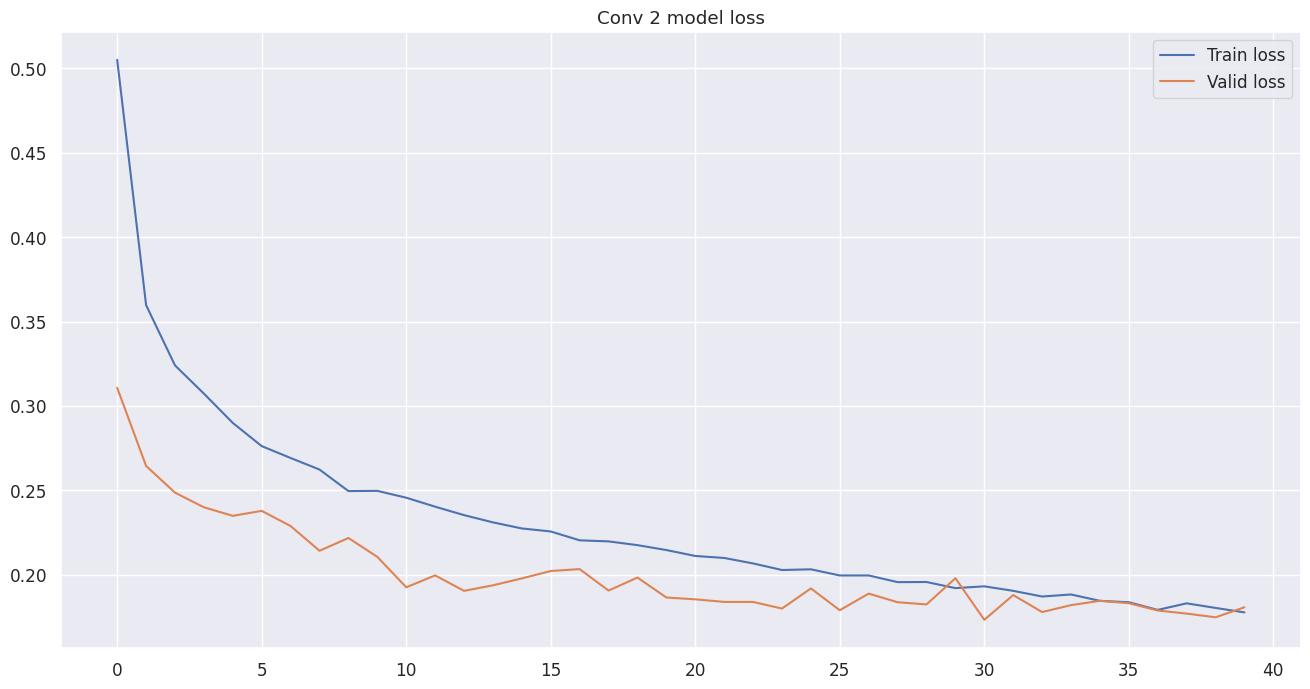

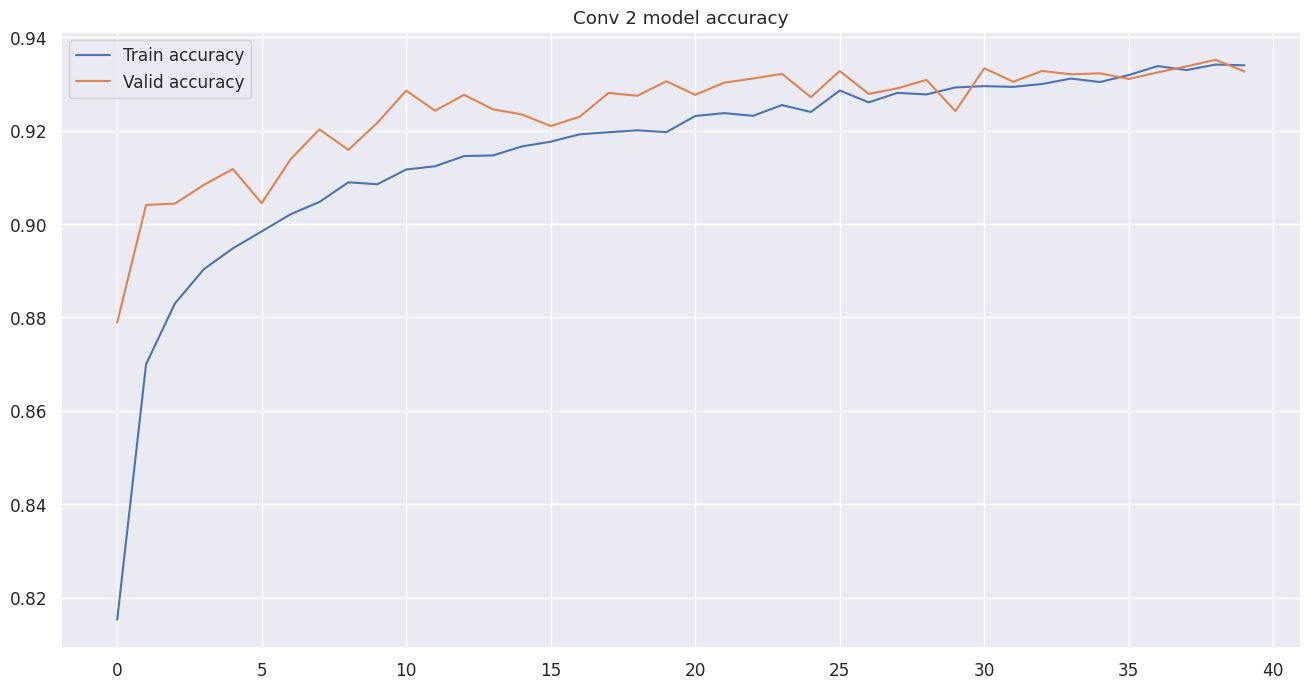

In [79]:
# 2-ой вариант Adam с lr=0.01
# почему так, для адама вообще большой шаг не подоходит (и этот тоже большой, но ради эксперимента можно)
from torch.optim import Adam


model2 = MyModelConv().to(device)

optimizer = Adam(model2.parameters(), lr=0.01)

fit(model2, train_loader, valid_loader, optimizer, loss_function, device, 40, 'Conv 2 model')

Как мы видим, адам с большим шагом действительно плох, график имеет слишком сильные помехи, даже с sgd не такие ужасный помехи были. Нам сильно повезло, что он не попал в плохой локальный минимум в конце 

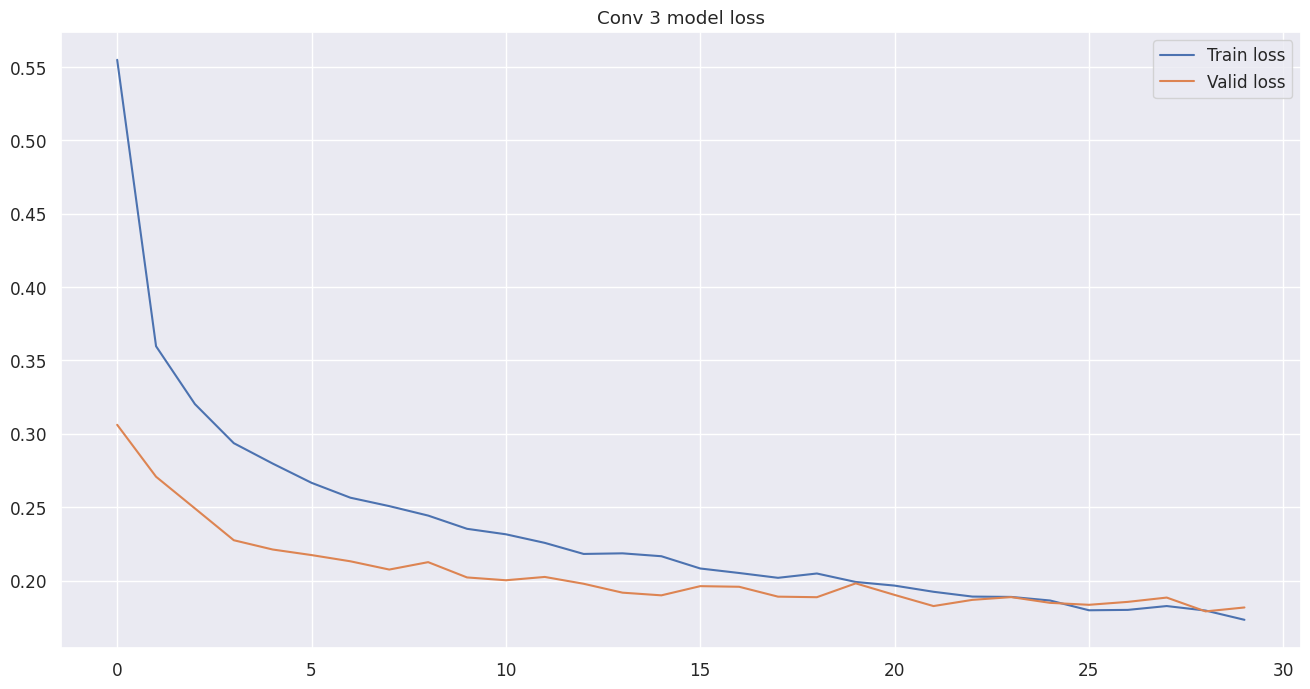

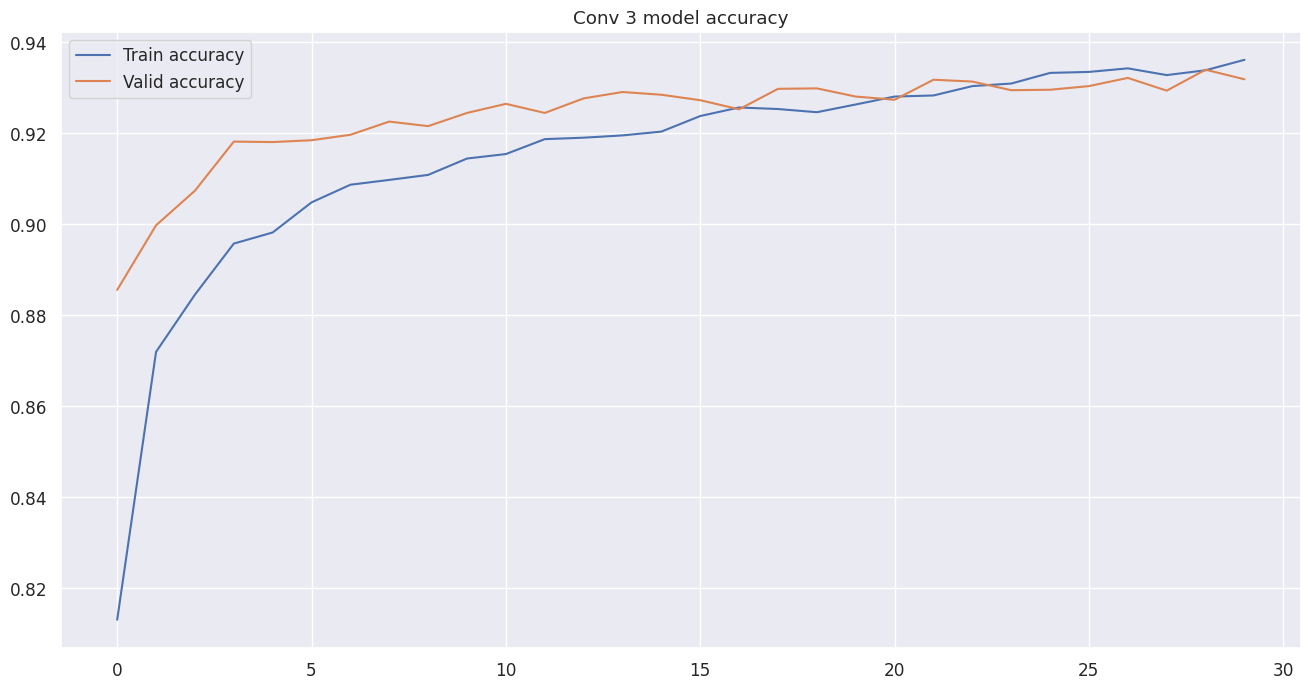

In [75]:
# 3-ий вариант Adam с lr=0.001
# то что вы предлагали
from torch.optim import Adam


model3 = MyModelConv().to(device)

optimizer = Adam(model3.parameters(), lr=0.001)

fit(model3, train_loader, valid_loader, optimizer, loss_function, device, 30, 'Conv 3 model')

шаг 0.001 немного сгладил помехи, да и в общем обучение стало стабильнее, не самый плохой вариант, также сошёлся быстрее всех за 1,5 минуты

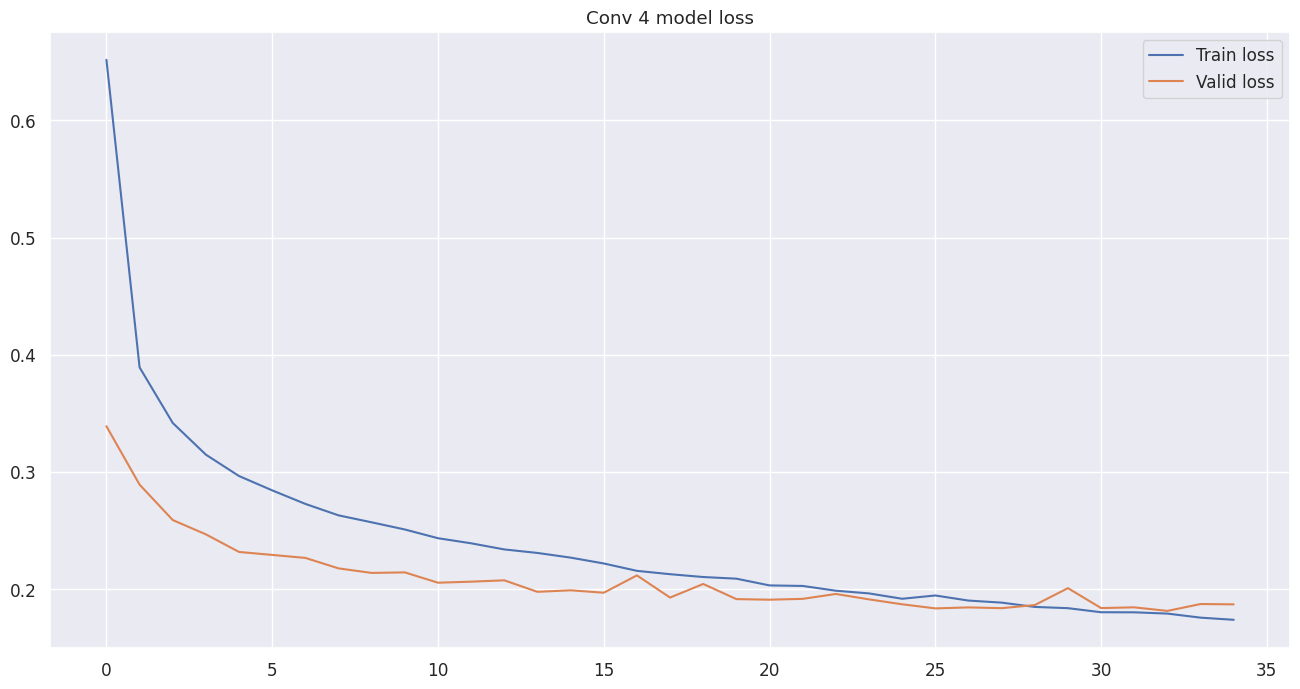

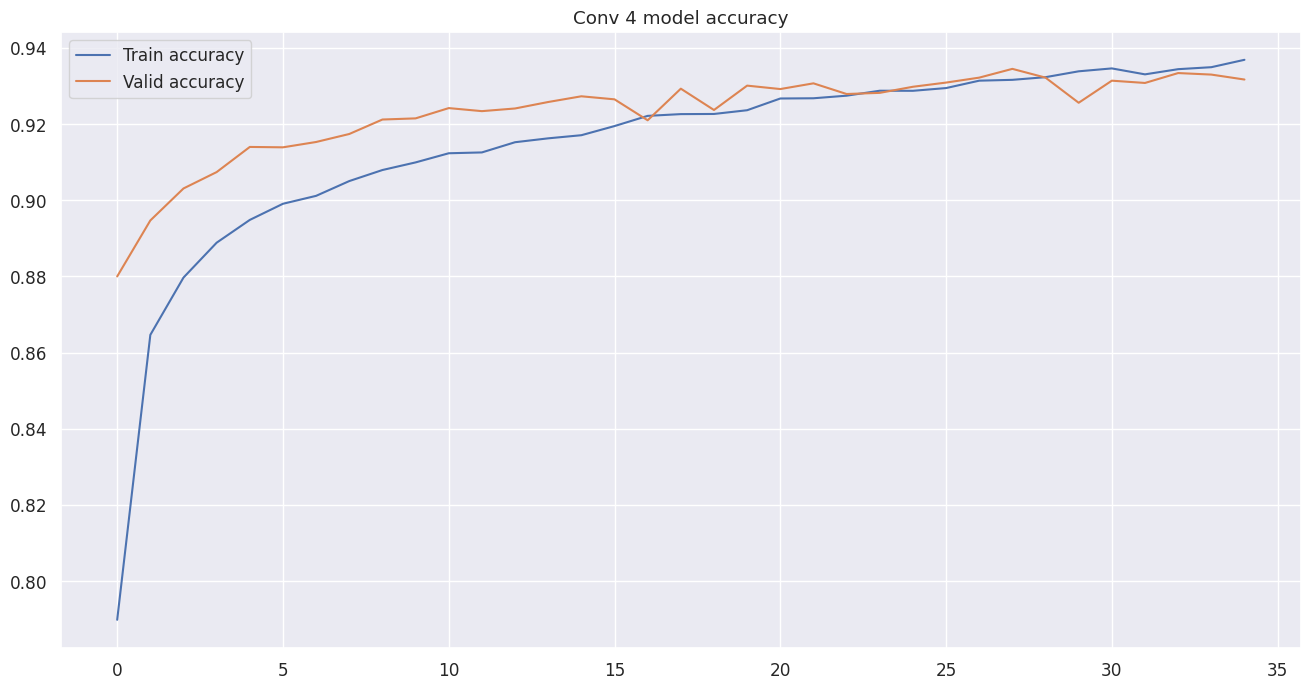

In [91]:
# 4-ый вариант Adam с lr=0.0005
# а что, если сделать шаг ещё меньше
from torch.optim import Adam


model4 = MyModelConv().to(device)

optimizer = Adam(model4.parameters(), lr=0.0005)

fit(model4, train_loader, valid_loader, optimizer, loss_function, device, 35, 'Conv 4 model')

ещё меньший шаг, хоть и оставил прежние помехи, смог сделать лучше score на валидационной выборке да и немного стабильнее показал себя

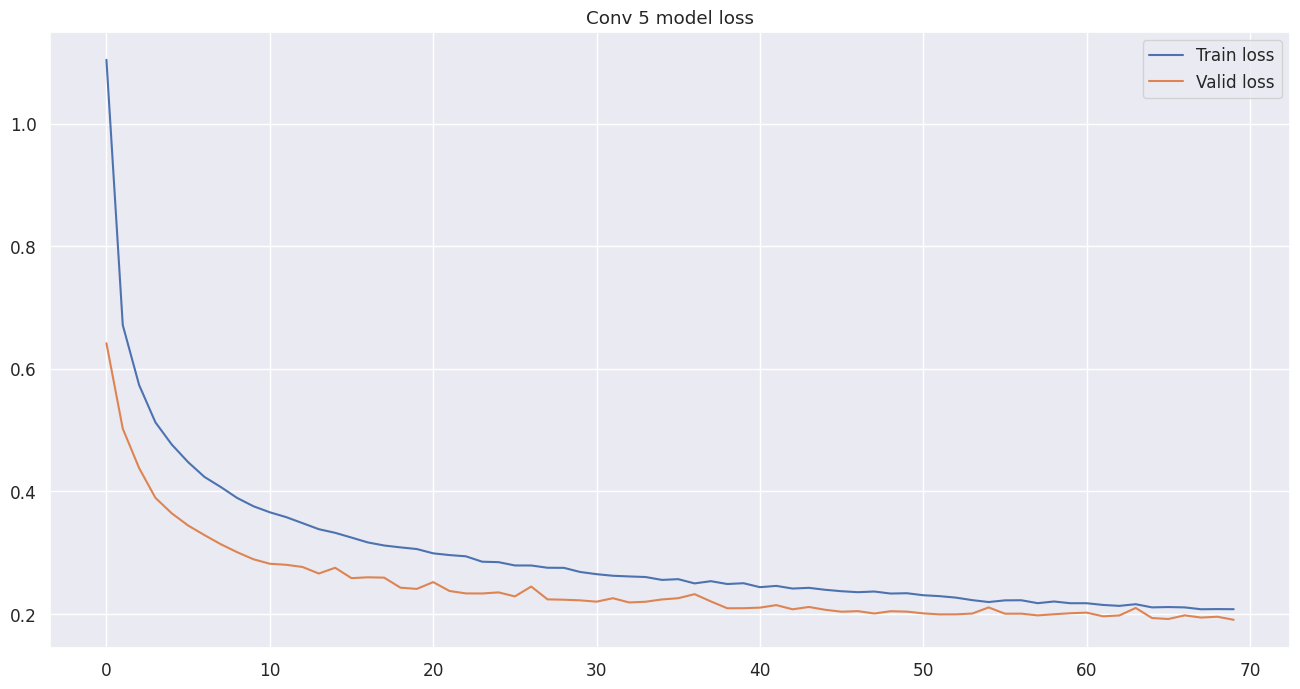

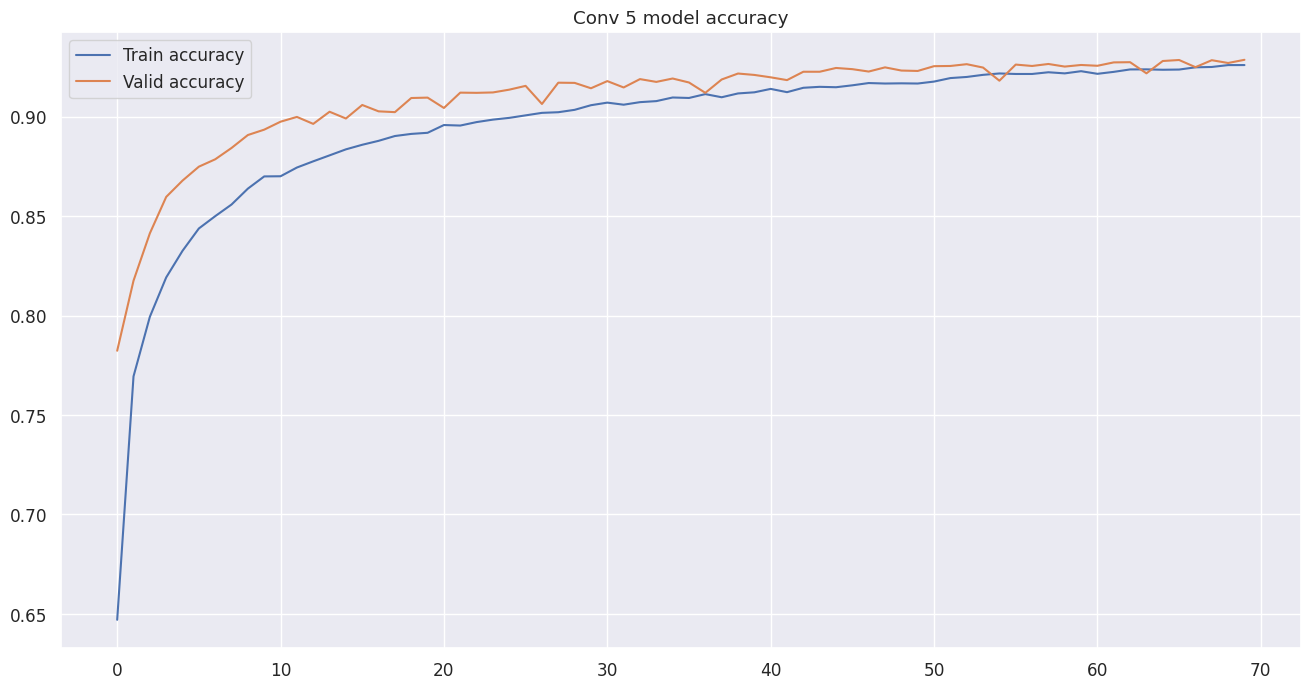

In [81]:
# 5-ый вариант SGD с lr=0.001
# с Adam мы закончили, теперь вернёмся к SGD
from torch.optim import SGD


model5 = MyModelConv().to(device)

optimizer = SGD(model5.parameters(), lr=0.001, momentum=0.9)

fit(model5, train_loader, valid_loader, optimizer, loss_function, device, 70, 'Conv 5 model')

Мы видим, что график уж очень медленно сходится, понятно, что это худший вариант, то есть для SGD шаг 0.001 слишком маленький, когда для adam в самый раз

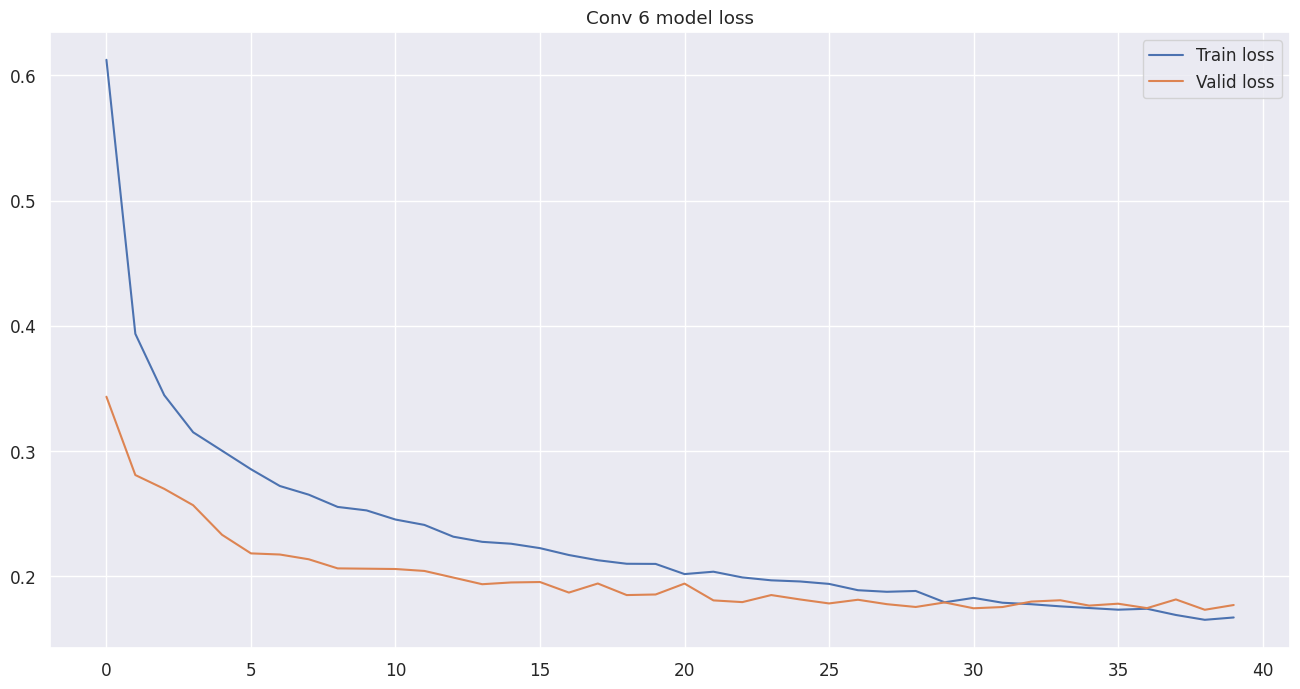

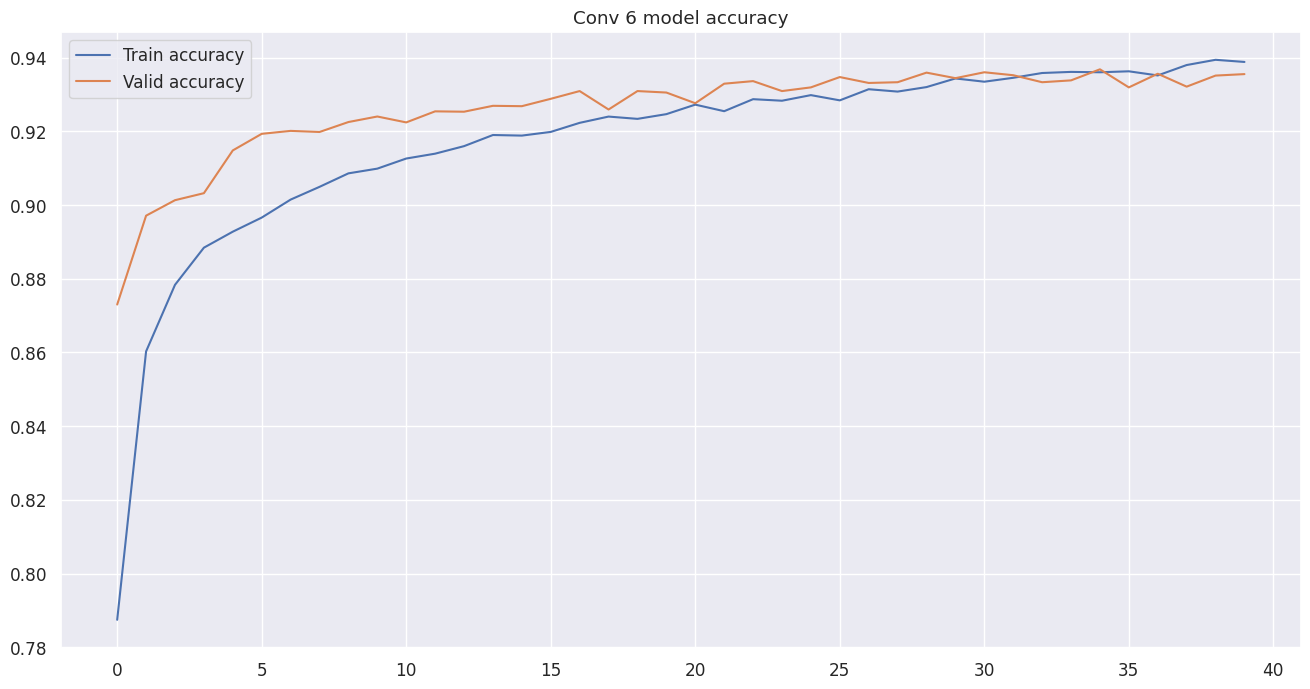

In [68]:
# 6-ый вариант SGD с lr=0.01
# SGD с lr=0.001 показал себя плохо, возможно этот покажет себя лучше
from torch.optim import SGD


model6 = MyModelConv().to(device)

optimizer = SGD(model6.parameters(), lr=0.01, momentum=0.9)

fit(model6, train_loader, valid_loader, optimizer, loss_function, device, 40, 'Conv 6 model')

Довольно неплохой график, но всё же помехи остались и быстро достиг своего плато

Также сейчас можно сказать, что практически все графики сошлись, что тоже хорошо

По аналогии с предыдущим заданием: проверяем accuraсy, уже без остальных метрик, так как понятно, что модель получится сбалансированной, и вероятность правильного определения класса (cm)

In [92]:
prediction1 = predict(model1, test_loader, device)
prediction2 = predict(model2, test_loader, device)
prediction3 = predict(model3, test_loader, device)
prediction4 = predict(model4, test_loader, device)
prediction5 = predict(model5, test_loader, device)
prediction6 = predict(model6, test_loader, device)
labels = get_labels(test_loader)

100%|██████████| 79/79 [00:00<00:00, 290.62it/s]


In [93]:
print("SGD lr=0.1:    ", torch.mean((prediction1 == labels).to(torch.float32)))
print("Adam lr=0.01:  ", torch.mean((prediction2 == labels).to(torch.float32)))
print("Adam lr=0.001: ", torch.mean((prediction3 == labels).to(torch.float32)))
print("Adam lr=0.0005:", torch.mean((prediction4 == labels).to(torch.float32)))
print("SGD lr=0.001:  ", torch.mean((prediction5 == labels).to(torch.float32)))
print("SGD lr=0.01:   ", torch.mean((prediction6 == labels).to(torch.float32)))

SGD lr=0.1:     tensor(0.9331)
Adam lr=0.01:   tensor(0.9314)
Adam lr=0.001:  tensor(0.9293)
Adam lr=0.0005: tensor(0.9290)
SGD lr=0.001:   tensor(0.9221)
SGD lr=0.01:    tensor(0.9289)


Вау, генераторы помех победили, то есть большой шаг решает (да, генерирует больше помех, но даёт возможность модели попрыгать по более удачным минимумам)

Посмотрим на матрицу ошибок, для SGD lr=0.1

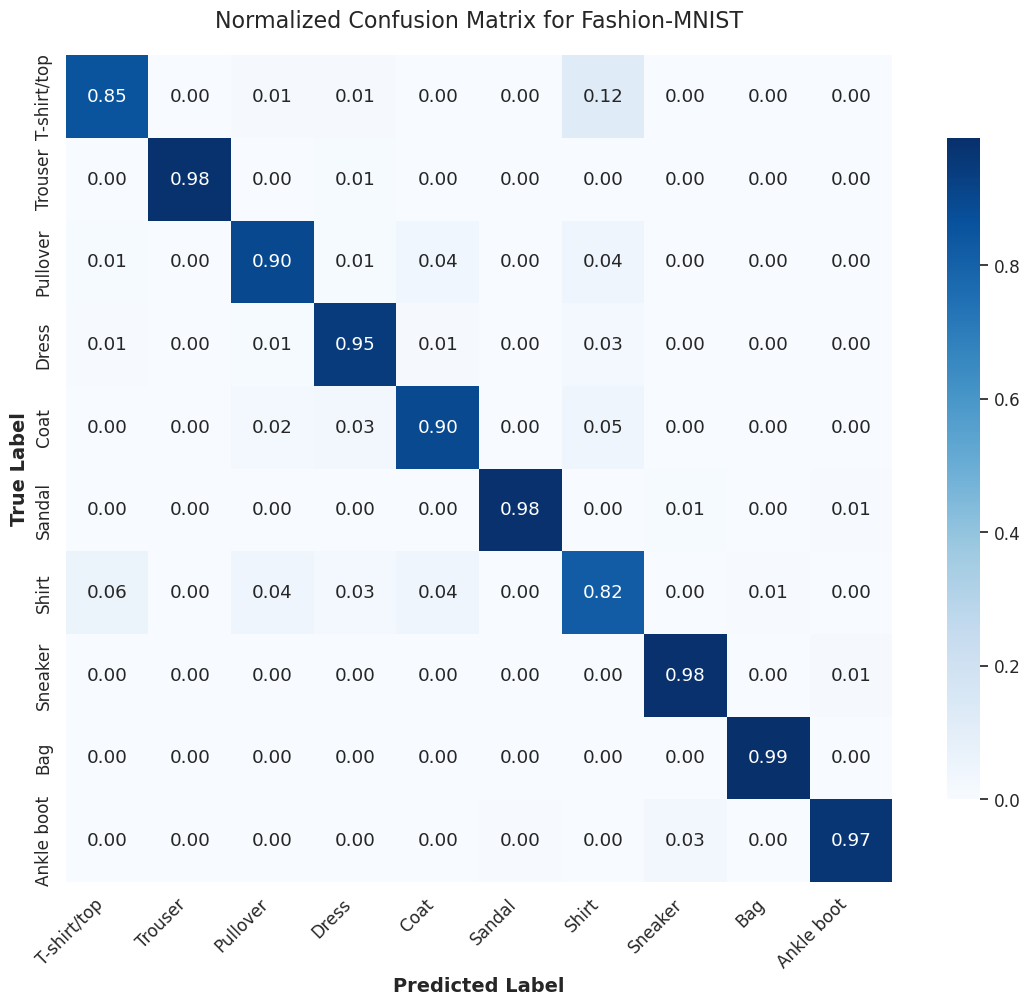

In [88]:
plot_confusion_matrix(labels, prediction1, classes)

#### **0.9331**

тут ситуация, в целом намного лучше, если говорить об обычной модели, но даже так осталась болячка в виде классов shirt и t-shirt, которые путаются между собой. Но мы видим, ощутимый прогресс (с 0.8969), что радует

а ошибок по классам стало меньше, что показывает эффективность свёрток, например, класс coat, который в прошлый раз распознавался с точностью 0.78 стал распознаваться на целых 0.12 больше, что очень хорошо

теперь мы получили довольно классный результат на тех же 200к параметрах и наши графики обучения, теперь получились неплохими. И SGD опять обошёл Adam в MNIST

Спасибо за дорешку, хотя бы лучше в графиках и как быстро подбирать гипер параметры разобрался

# **Задание 3 Датасет**

Вспомним архитектуру из прошлого задания

In [69]:
import torch.nn as nn
from torchsummary import summary

class MyModelConv(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.net = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding=1), # 28 x 28 x 16
            nn.BatchNorm2d(16),
            nn.ReLU(),

            nn.MaxPool2d(2), # 14 x 14 x 16

            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1), # 14 x 14 x 32
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.MaxPool2d(2), # 7 x 7 x 32

            nn.Flatten(),

            # по итогу у нас 32 фильтра, 7 x 7 пикселей - 1568 

            nn.Linear(1568, 784), # просто расширим нашу старую модельку под свёртку
            nn.BatchNorm1d(784),
            nn.ReLU(),
            nn.Dropout(0.3),
            
            nn.Linear(784, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),
            
            nn.Linear(128, 10)
        )
    
    def forward(self, x):
        x = self.net(x)
        return x
    

model = MyModelConv().to(device)
summary(model, input_size=(1, 28, 28))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 16, 28, 28]             160
       BatchNorm2d-2           [-1, 16, 28, 28]              32
              ReLU-3           [-1, 16, 28, 28]               0
         MaxPool2d-4           [-1, 16, 14, 14]               0
            Conv2d-5           [-1, 32, 14, 14]           4,640
       BatchNorm2d-6           [-1, 32, 14, 14]              64
              ReLU-7           [-1, 32, 14, 14]               0
         MaxPool2d-8             [-1, 32, 7, 7]               0
           Flatten-9                 [-1, 1568]               0
           Linear-10                  [-1, 784]       1,230,096
      BatchNorm1d-11                  [-1, 784]           1,568
             ReLU-12                  [-1, 784]               0
          Dropout-13                  [-1, 784]               0
           Linear-14                  [

Сначала посчитаем отклонение

In [82]:
means = (train_dataset.data / 255).mean(axis=(0, 1, 2))

means

tensor(0.2860)

In [ ]:
stds = (train_dataset.data / 255).std(axis=(0, 1, 2))

stds

tensor(0.3530)

Задаём дополнительные преобразования датасету, где вставим значения mean и stds в Normalize

In [84]:
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    transforms.ToTensor(),
    transforms.Normalize(mean=means, std=stds)
])

valid_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=means, std=stds)
])

train_dataset1 = datasets.FashionMNIST(root="mnist", train=True, download=True, transform=train_transform)
train_loader1 = DataLoader(train_dataset1, batch_size=128, shuffle=True, num_workers=8, pin_memory=True)

valid_dataset1 = datasets.FashionMNIST(root="mnist", train=False, download=True, transform=valid_transform)
valid_loader1 = DataLoader(valid_dataset1, batch_size=128, shuffle=False, num_workers=8, pin_memory=True)

Приступим к обучению (возьму Adam, который я подобрал в прошлом задании)

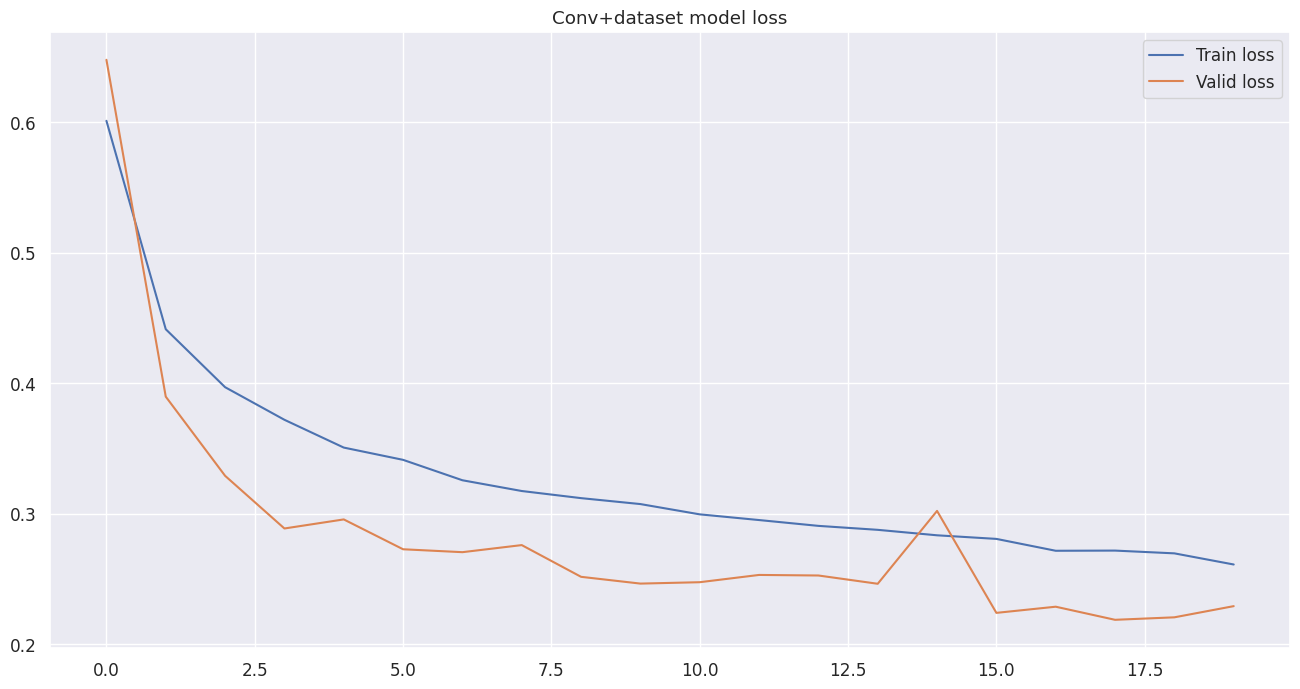

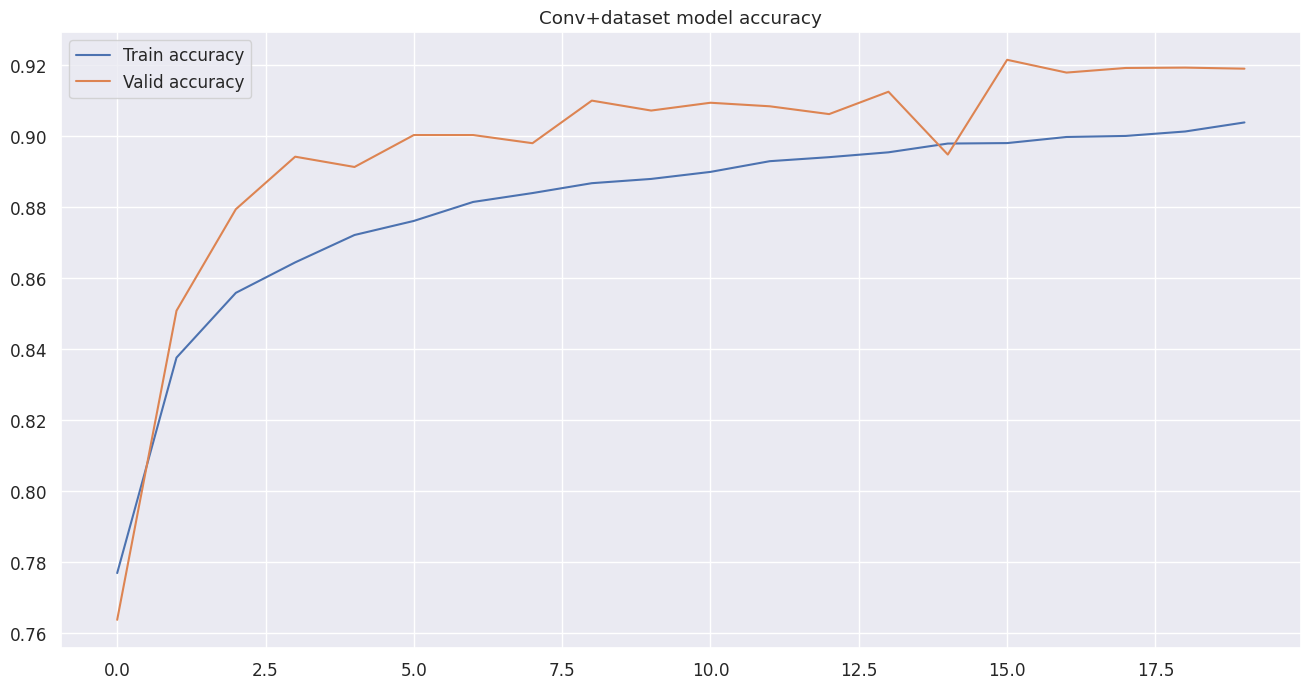

In [ ]:
from torch.optim import Adam


model = MyModelConv().to(device)

optimizer = Adam(model.parameters(), lr=0.0001)

fit(model, train_loader1, valid_loader1, optimizer, loss_function, device, 20, 'Conv+dataset model')

В принципе, обучение прошло неплохо, однако видно, что мы ещё не получили переобучения, а значит модели ещё есть потенциал выдать больший score (увеличу до 50-ти)

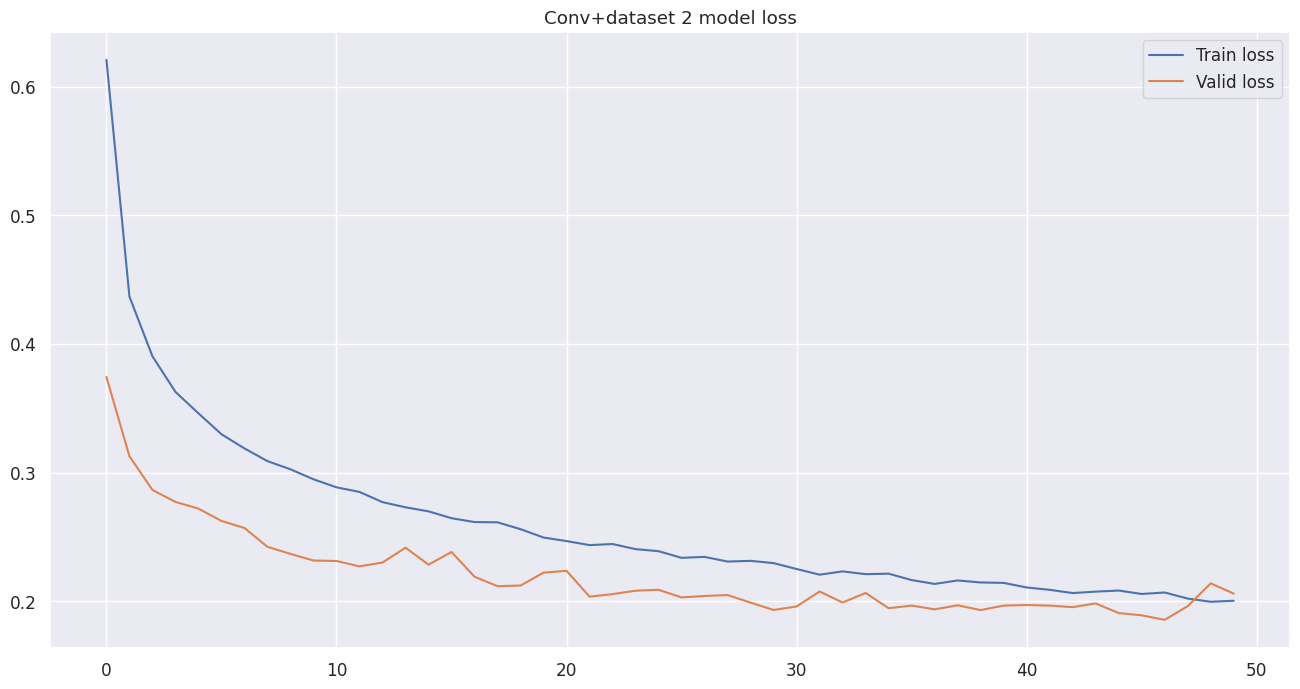

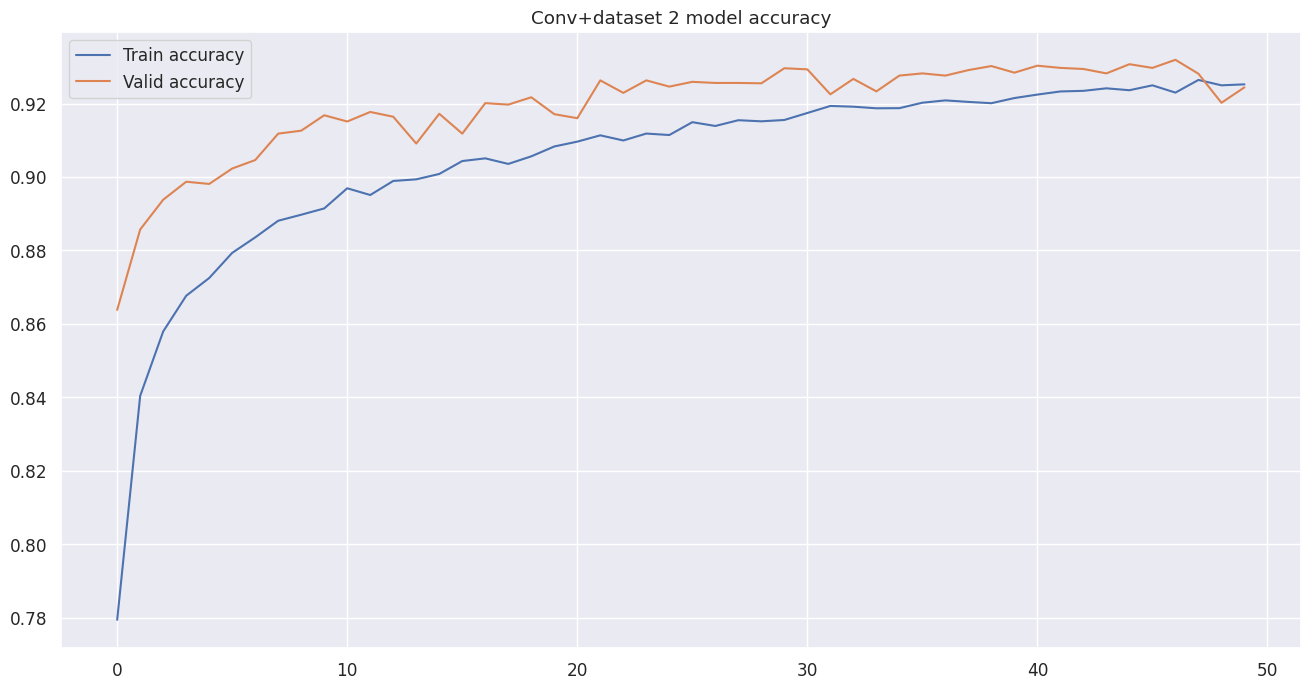

In [88]:
from torch.optim import Adam


model = MyModelConv().to(device)

optimizer = Adam(model.parameters(), lr=0.001)

fit(model, train_loader1, valid_loader1, optimizer, loss_function, device, 50, 'Conv+dataset 2 model')

Очевидно, то мы получили переобучение, давайте проверим acc и матрицу ошибок

In [89]:
prediction = predict(model, valid_loader1, device)
labels = get_labels(valid_loader1)

100%|██████████| 79/79 [00:00<00:00, 232.61it/s]


In [90]:
torch.mean((prediction == labels).to(torch.float32))

tensor(0.9244)

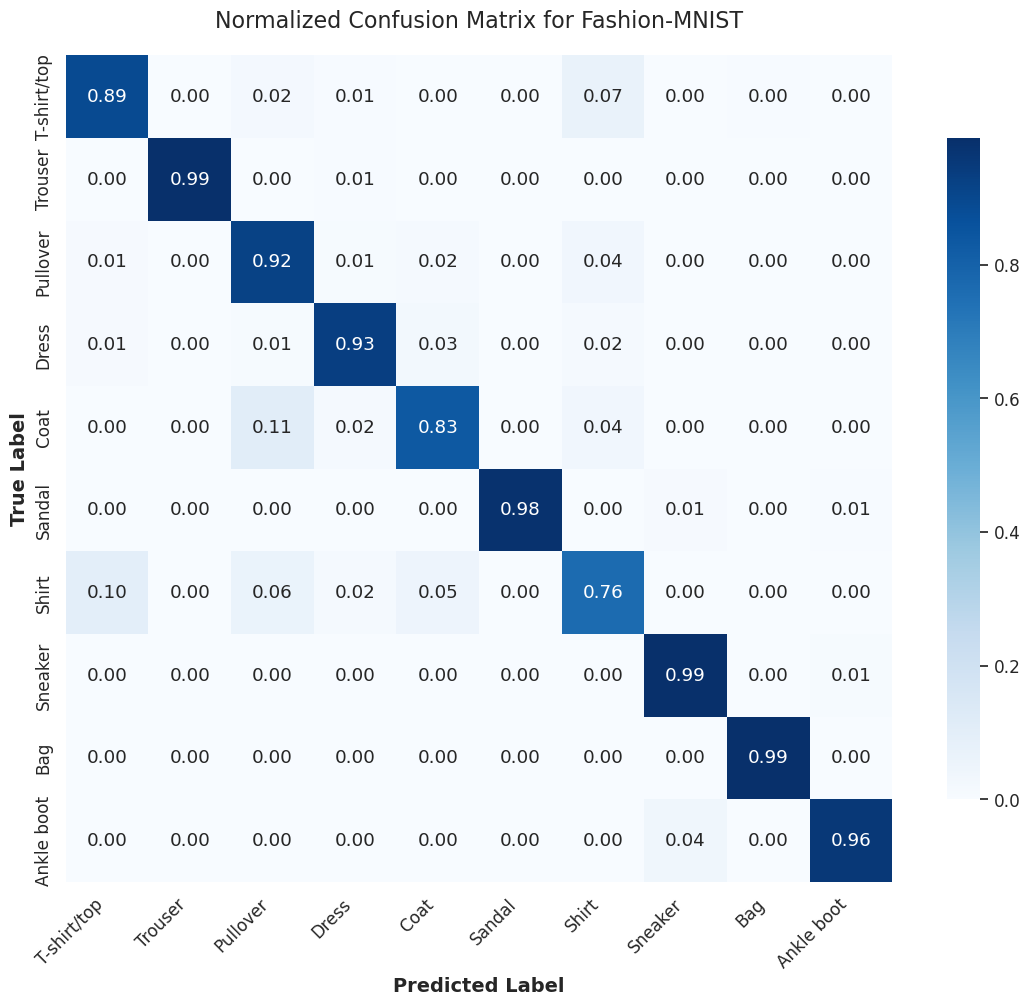

In [91]:
plot_confusion_matrix(labels, prediction, classes)

#### **0.9244** 

Несмотря на незначительное снижение итоговой точности до 0.9244, использование transform - хорошая вещь, так как

* оно стабилизировало наше обучение (пришлось обучать до 50 эпох, чтобы увидеть что-то отдалённо похожее переобучение)

* Благодаря RandomAffine и HorizontalFlip, модель стала устойчивой к геометрическим искажениям

# **Задание 4 Метод скипа (Шучу тут Skip-Connections)**

Добавьте skip-connection. Выведите summary модели, посмотрите на графики обучения, сделайте выводы.

Вспомним предыдущую модельку

In [92]:
import torch.nn as nn
from torchsummary import summary

class MyModelConv(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.net = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding=1), # 28 x 28 x 16
            nn.BatchNorm2d(16),
            nn.ReLU(),

            nn.MaxPool2d(2), # 14 x 14 x 16

            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1), # 14 x 14 x 32
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.MaxPool2d(2), # 7 x 7 x 32

            nn.Flatten(),

            # по итогу у нас 32 фильтра, 7 x 7 пикселей - 1568 

            nn.Linear(1568, 784), # просто расширим нашу старую модельку под свёртку
            nn.BatchNorm1d(784),
            nn.ReLU(),
            nn.Dropout(0.3),
            
            nn.Linear(784, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),
            
            nn.Linear(128, 10)
        )
    
    def forward(self, x):
        x = self.net(x)
        return x
    

model = MyModelConv().to(device)
summary(model, input_size=(1, 28, 28))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 16, 28, 28]             160
       BatchNorm2d-2           [-1, 16, 28, 28]              32
              ReLU-3           [-1, 16, 28, 28]               0
         MaxPool2d-4           [-1, 16, 14, 14]               0
            Conv2d-5           [-1, 32, 14, 14]           4,640
       BatchNorm2d-6           [-1, 32, 14, 14]              64
              ReLU-7           [-1, 32, 14, 14]               0
         MaxPool2d-8             [-1, 32, 7, 7]               0
           Flatten-9                 [-1, 1568]               0
           Linear-10                  [-1, 784]       1,230,096
      BatchNorm1d-11                  [-1, 784]           1,568
             ReLU-12                  [-1, 784]               0
          Dropout-13                  [-1, 784]               0
           Linear-14                  [

Добавим ей скип connections (сделаем аналог Resnet)

In [ ]:
import torch.nn as nn
from torchsummary import summary


class ResidualConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels=in_channels, out_channels=out_channels, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU()

        self.conv2 = nn.Conv2d(in_channels=out_channels, out_channels=out_channels, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.shortcut = nn.Sequential()
        if in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1),
                nn.BatchNorm2d(out_channels)
            )
    
    def forward(self, x):
        identity = self.shortcut(x)
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        
        out = self.conv2(out)
        out = self.bn2(out)
        return self.relu(out + identity)

    
class Resnet(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Conv2d(1, 16, kernel_size=3, padding=1) # 28 x 28 x 16
        self.bn0 = nn.BatchNorm2d(16)

        self.res_conv1 = ResidualConvBlock(16, 16) # 28 x 28 x 16
        self.pool1 = nn.MaxPool2d(2) # 14 x 14 x 16

        self.res_conv2 = ResidualConvBlock(16, 32) # 14 x 14 x 32
        self.pool2 = nn.MaxPool2d(2) # 7 x 7 x 32

        self.flatten = nn.Flatten()

        # Специально уменьшил число параметров, чтобы потом показать в чём разница моделей с skip и без skip connections
        self.fc1 = nn.Linear(7 * 7 * 32, 512)
        self.bn1 = nn.BatchNorm1d(512)
        self.relu1 = nn.ReLU()
        self.drop1 = nn.Dropout(0.3)

        self.fc3 = nn.Linear(512, 10)
    
    def forward(self, x):
        out = self.conv(x)
        out = self.bn0(out)
        out = self.res_conv1(out)
        out = self.pool1(out)
        out = self.res_conv2(out)
        out = self.pool2(out)

        out = self.flatten(out)

        out = self.fc1(out)
        out = self.bn1(out)
        out = self.relu1(out)
        out = self.drop1(out)

        out = self.fc3(out)
        return out
    

model = Resnet().to(device)
summary(model, input_size=(1, 28, 28))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 16, 28, 28]             160
       BatchNorm2d-2           [-1, 16, 28, 28]              32
            Conv2d-3           [-1, 16, 28, 28]           2,320
       BatchNorm2d-4           [-1, 16, 28, 28]              32
              ReLU-5           [-1, 16, 28, 28]               0
            Conv2d-6           [-1, 16, 28, 28]           2,320
       BatchNorm2d-7           [-1, 16, 28, 28]              32
              ReLU-8           [-1, 16, 28, 28]               0
 ResidualConvBlock-9           [-1, 16, 28, 28]               0
        MaxPool2d-10           [-1, 16, 14, 14]               0
           Conv2d-11           [-1, 32, 14, 14]             544
      BatchNorm2d-12           [-1, 32, 14, 14]              64
           Conv2d-13           [-1, 32, 14, 14]           4,640
      BatchNorm2d-14           [-1, 32,

Вспомним, как мы изменили датасет в прошлом задании

In [113]:
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    transforms.ToTensor(),
    transforms.Normalize(mean=means, std=stds)
])

valid_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=means, std=stds)
])

train_dataset1 = datasets.FashionMNIST(root="mnist", train=True, download=True, transform=train_transform)
train_loader1 = DataLoader(train_dataset1, batch_size=128, shuffle=True, num_workers=8, pin_memory=True)

valid_dataset1 = datasets.FashionMNIST(root="mnist", train=False, download=True, transform=valid_transform)
valid_loader1 = DataLoader(valid_dataset1, batch_size=128, shuffle=False, num_workers=8, pin_memory=True)

И обучение с Adam на 50 эпох с lr=0.001

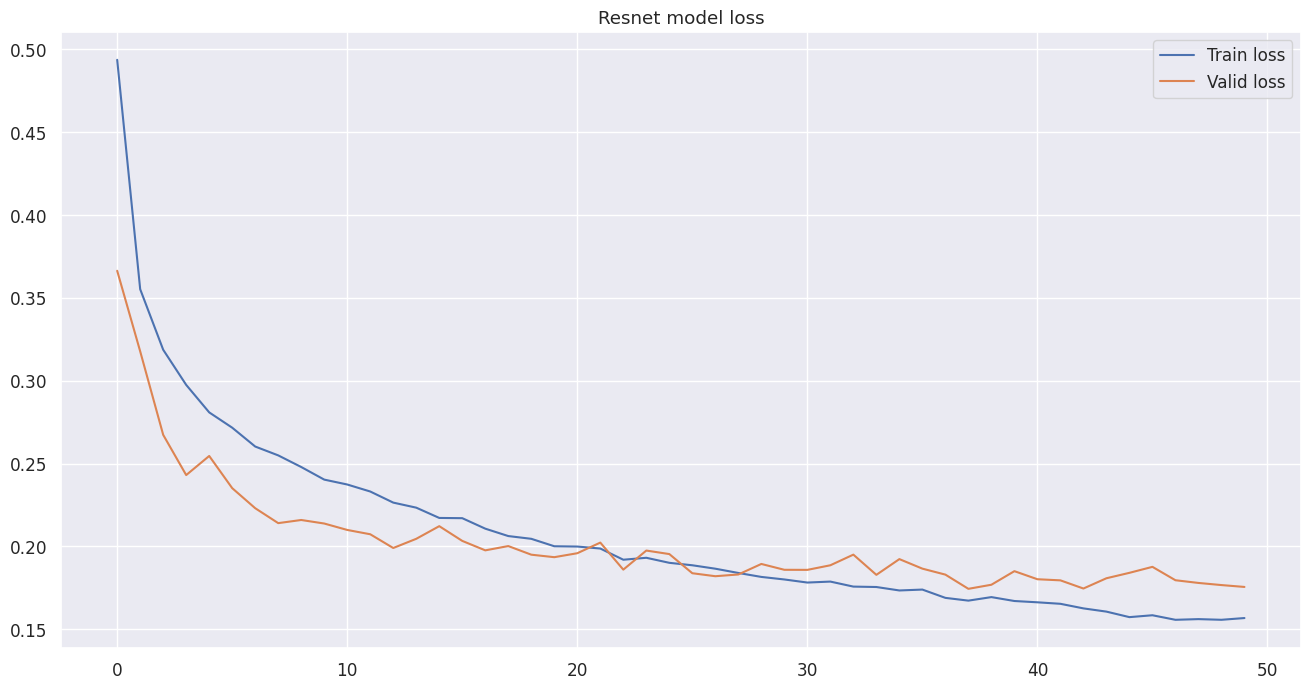

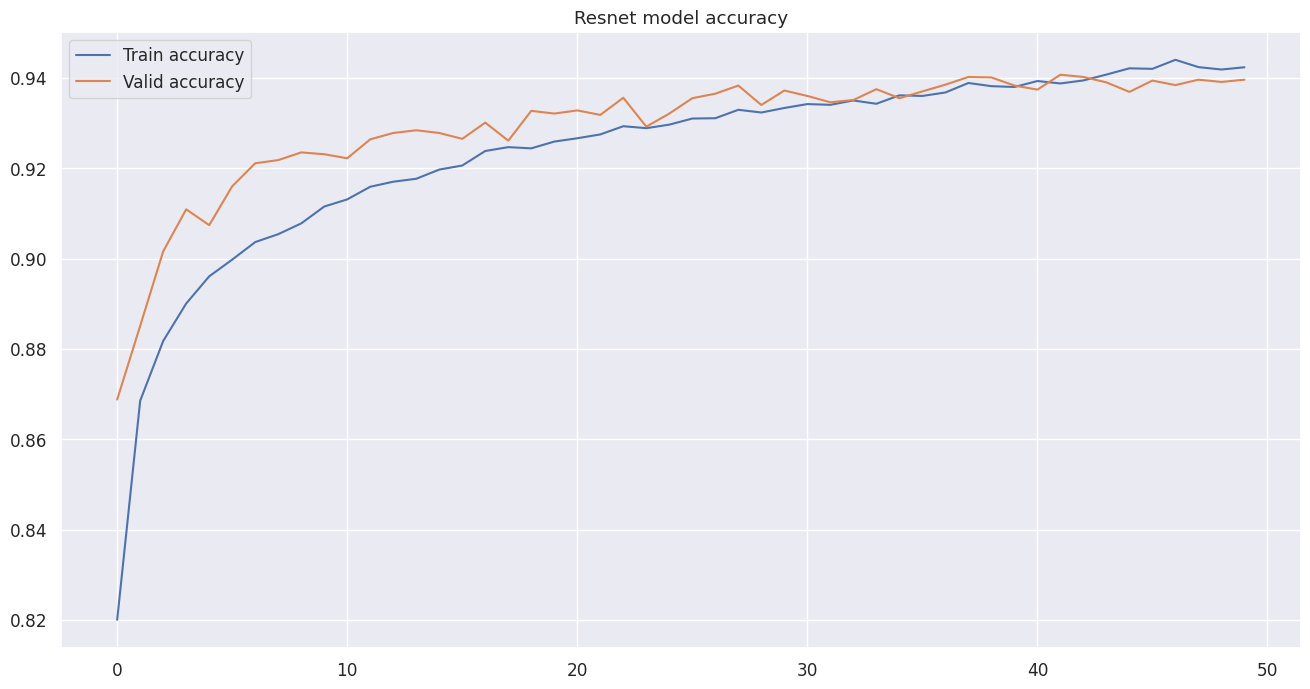

In [114]:
from torch.optim import Adam


model = Resnet().to(device)

optimizer = Adam(model.parameters(), lr=0.001)

fit(model, train_loader1, valid_loader1, optimizer, loss_function, device, 50, 'Resnet model')

Видно, что модель достигла своего плато, значит обучение провелось нормально и нам не нужно менять параметры

По старинке проверим accuracy и cm

In [115]:
prediction = predict(model, valid_loader1, device)
labels = get_labels(valid_loader1)

100%|██████████| 79/79 [00:00<00:00, 176.21it/s]


In [116]:
torch.mean((prediction == labels).to(torch.float32))

tensor(0.9396)

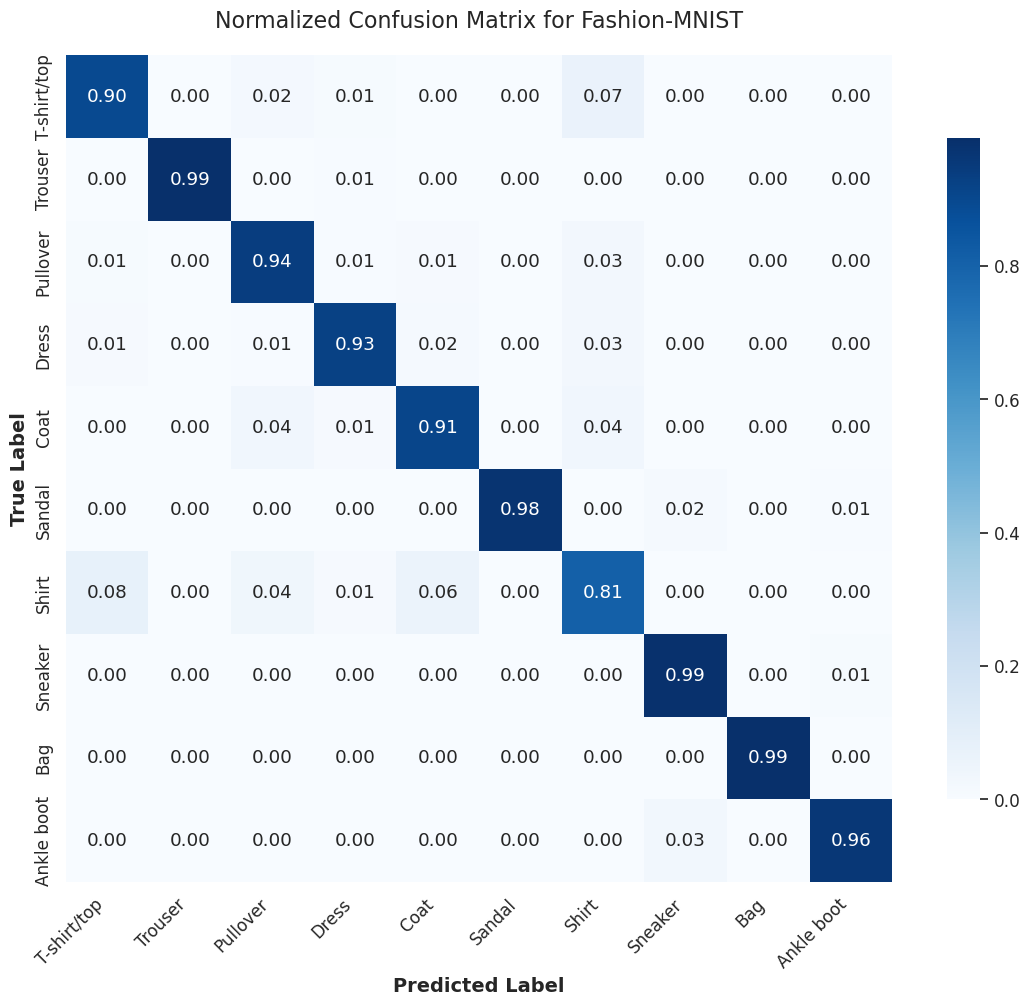

In [117]:
plot_confusion_matrix(labels, prediction, classes)

И наконец, последний вывод (по 4-ому заданию)

#### **0.9396**

Очевидно, что это мой самый большой результат (Как улучшался score 0.89 -> 0.92 -> 0.94), также наш resnet c 800к параметрами, показал лучшие результаты, чем cnn с 1,5 млн параметрами, что говорит о том, что наш skip-connections значительно улучшают работу нейросети

К сожалению, нам не удалось устранить ошибки в классе shirt до конца, и по сути только он отделяет нас от результатов выше 0.97 (так как 60% процентов ошибок в стобцах и колонках по этому классу)

Также она показала хорошую стабильность на обучении